<a href="https://colab.research.google.com/github/ikoghoddds-bit/Data-Science-Portfolio-C21/blob/main/Projects/Project-1/Joseph_Project_1_To_Do_List.data_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Project 1 – To Do List



## Problem Definition

- The goal is to take customer information based on historical transaction records and predict whether or not a customer will make a transaction. This is a binary classification problem since the customer either makes a transaction, or doesn't. This project will use Naive Bayes Gaussian classification.


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from google.colab import userdata
import os

## Load Data from Hugging Face

In [7]:
hf_url = "https://huggingface.co/datasets/JosephIkogho/Data_Science-21/resolve/main/transactions.parquet"
hf_url

'https://huggingface.co/datasets/JosephIkogho/Data_Science-21/resolve/main/transactions.parquet'

In [8]:
dataframe_bak01 = pd.read_parquet( hf_url )
dataframe_bak01.shape

(180000, 51)

## Exploratory Data Analysis






6. Produce some visual analysis of the data – like plots showing the distributions of all variables. Recall that Gaussian Naive Bayes assumes the predictors are normally distributed. Note: you might have to do multiple plots in groups.

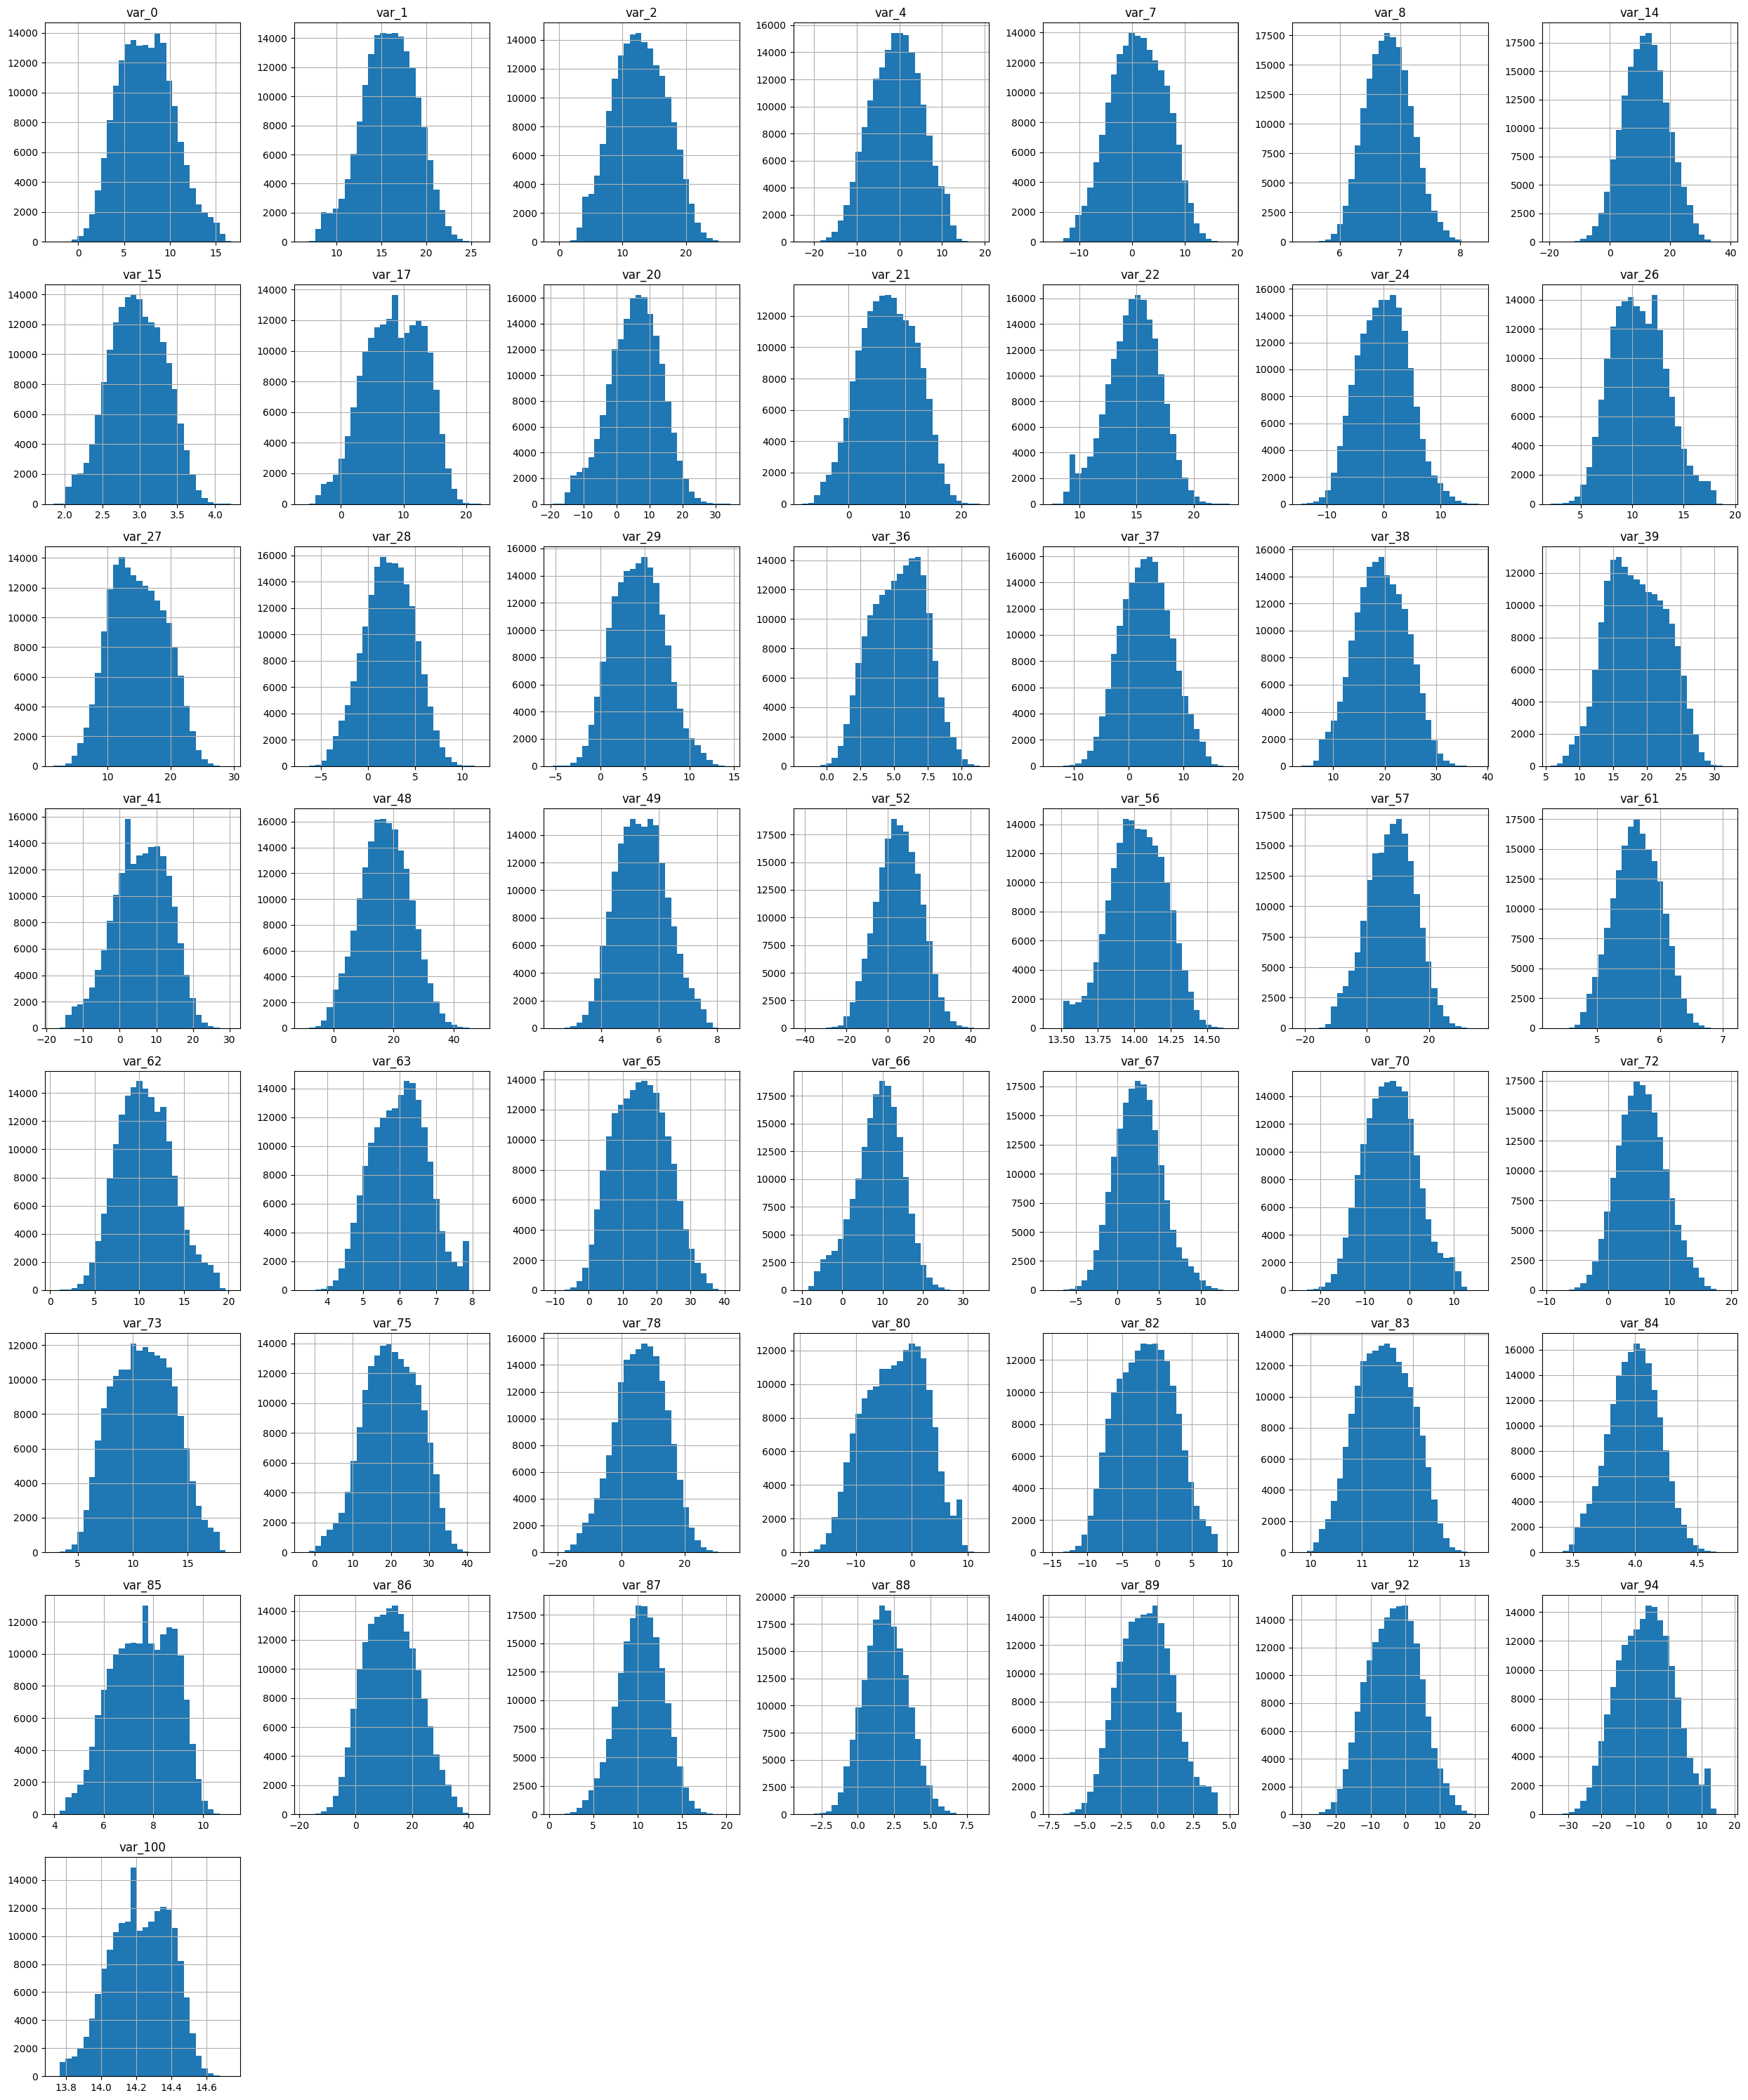

In [12]:
predictors = dataframe_bak01.drop(columns='target')
predictors.hist(figsize=(25, 30), bins=30)
plt.tight_layout()
plt.show()

7. NOTE: the ‘target’ column indicates a successful transaction (‘1’) or a no-transaction (‘0’). Verify these are the only values in that column.

In [14]:
dataframe_bak01['target'].isnull().sum()

np.int64(0)

8. Check the correlation values between all predictor columns to ensure there are no substantial correlations between predictors. This is important to support the decision to classify the ‘target’ using Naïve Bayes.

In [16]:
dataframe_transaction = dataframe_bak01[dataframe_bak01['target'] == 1.0].copy()
dataframe_non_transaction = dataframe_bak01[dataframe_bak01['target'] == 0.0].copy()
print(dataframe_transaction.shape)
print(dataframe_non_transaction.shape)

(18040, 51)
(161960, 51)


In [20]:
import seaborn as sns

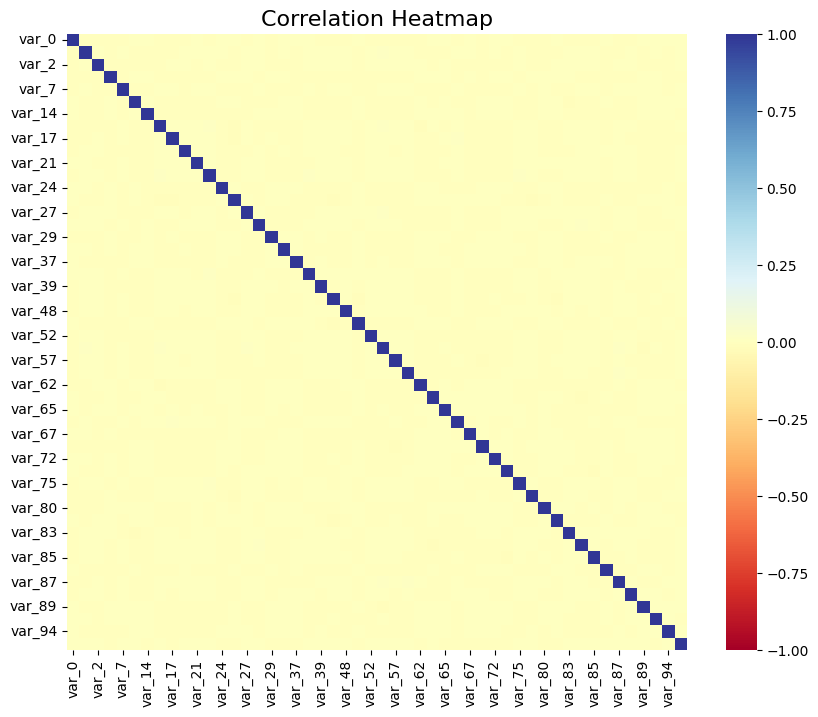

In [21]:
# Drop 'Unnamed: 0' so it doesn't clutter your heatmap
corr_clean = dataframe_bak01.drop(columns=['target']).corr(numeric_only=True)

# Plot the clean heatmap without overlapping text numbers
plt.figure(figsize=(10, 8))  # Increased size to give labels breathing room
sns.heatmap(corr_clean, cmap='RdYlBu', annot=False, vmin=-1, vmax=1)
plt.title("Correlation Heatmap", fontsize=16)
plt.show()

In [25]:
X = dataframe_bak01.drop(columns=['target']).copy()
y = dataframe_bak01['target'].copy()

print(features.shape)
print(target.shape)

(180000, 50)
(180000,)



11. Define a Gaussian Naïve Bayes model using Sklearn.



In [26]:
from sklearn.naive_bayes import GaussianNB
model = GaussianNB()
print(model)

GaussianNB()


12. Divide the two data frames you created in step #10 into training and testing subsets.


In [27]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)
print(X_train.shape)
print(X_test.shape)

(144000, 50)
(36000, 50)


13. Train the model using the training subset of the dataset.


In [28]:
model.fit(X_train, y_train)

GaussianNB()

14. Test the model using the testing subset of the dataset. Calculate and report the accuracy.


In [29]:
from sklearn.metrics import accuracy_score
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy}")

Accuracy: 0.9109166666666667


15. Perform a cross-validation loop to calculate the accuracy of your model. Report that accuracy. How does it compare to the accuracy you calculated in #14?


In [30]:
from sklearn.model_selection import cross_val_score
scores = cross_val_score(model, X, y, cv=5)
print(f"Cross-validation scores: {scores}")
print(f"Mean accuracy: {scores.mean()}")

Cross-validation scores: [0.91066667 0.91186111 0.91038889 0.91119444 0.91252778]
Mean accuracy: 0.9113277777777778


16. Plot a histogram of the accuracy scores you generated in your cross-validation loop. What do you notice about the distribution of accuracy scores?


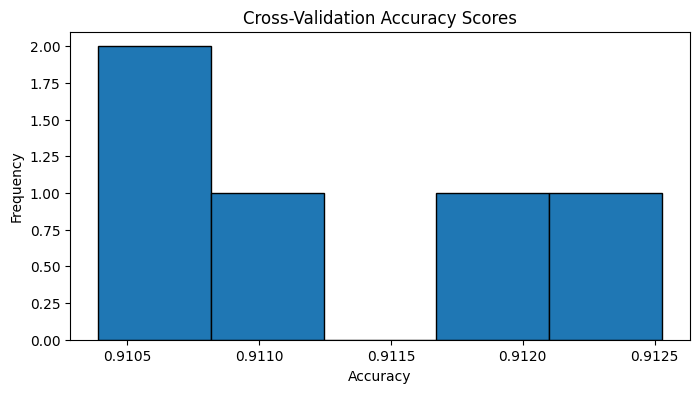

In [31]:
plt.figure(figsize=(8, 4))
plt.hist(scores, bins=5, edgecolor='black')
plt.title('Cross-Validation Accuracy Scores')
plt.xlabel('Accuracy')
plt.ylabel('Frequency')
plt.show()

17.  Present the confusion matrix and the results of your Classification Report (sklearn.metrics.classification_report). What do you notice?



In [32]:
from sklearn.metrics import confusion_matrix, classification_report
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[31983   419]
 [ 2788   810]]
              precision    recall  f1-score   support

         0.0       0.92      0.99      0.95     32402
         1.0       0.66      0.23      0.34      3598

    accuracy                           0.91     36000
   macro avg       0.79      0.61      0.64     36000
weighted avg       0.89      0.91      0.89     36000



18. The training data is very skewed towards non-successful transactions (about 90% of the training data has ‘target’==0). Remove enough non-successful transaction rows so that your remaining training data is 50%/50% split between successful and non-successful transactions. Hint: you can use the data frames you created in step #9.


In [33]:
dataframe_balanced = pd.concat([
    dataframe_transaction,
    dataframe_non_transaction.sample(n=len(dataframe_transaction), random_state=42)
])
print(dataframe_balanced['target'].value_counts())
print(dataframe_balanced.shape)

target
1.0    18040
0.0    18040
Name: count, dtype: int64
(36080, 51)


In [35]:
X_bal = dataframe_balanced.drop(columns=['target']).copy()
y_bal = dataframe_balanced['target'].copy()
scores_bal = cross_val_score(model, X_bal, y_bal, cv=5)
print(f"Balanced CV scores: {scores_bal}")
print(f"Balanced mean accuracy: {scores_bal.mean()}")

Balanced CV scores: [0.75207871 0.75970067 0.74833703 0.75207871 0.75817627]
Balanced mean accuracy: 0.7540742793791574


20. Repeat the cross-validation process on this data set. Report what your cross-validation accuracy is in this 50/50 case.

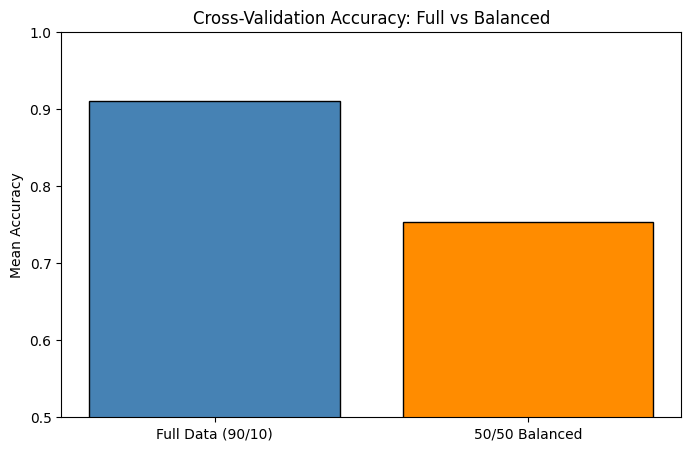

In [36]:
plt.figure(figsize=(8, 5))
plt.bar(['Full Data (90/10)', '50/50 Balanced'],
        [scores.mean(), scores_bal.mean()],
        color=['steelblue', 'darkorange'],
        edgecolor='black')
plt.title('Cross-Validation Accuracy: Full vs Balanced')
plt.ylabel('Mean Accuracy')
plt.ylim(0.5, 1.0)
plt.show()

## Data Visualization


20. Compare the results of your cross-validation with the whole training data and the reduced 50/50 training data



In [37]:
X_train_bal, X_test_bal, y_train_bal, y_test_bal = train_test_split(
    X_bal, y_bal, test_size=0.2, random_state=42)
model.fit(X_train_bal, y_train_bal)
y_pred_bal = model.predict(X_test_bal)

print(confusion_matrix(y_test_bal, y_pred_bal))
print(classification_report(y_test_bal, y_pred_bal))

[[2759  845]
 [ 917 2695]]
              precision    recall  f1-score   support

         0.0       0.75      0.77      0.76      3604
         1.0       0.76      0.75      0.75      3612

    accuracy                           0.76      7216
   macro avg       0.76      0.76      0.76      7216
weighted avg       0.76      0.76      0.76      7216



21. Present the confusion matrix and the results of your Classification Report (sklearn.metrics.classification_report)


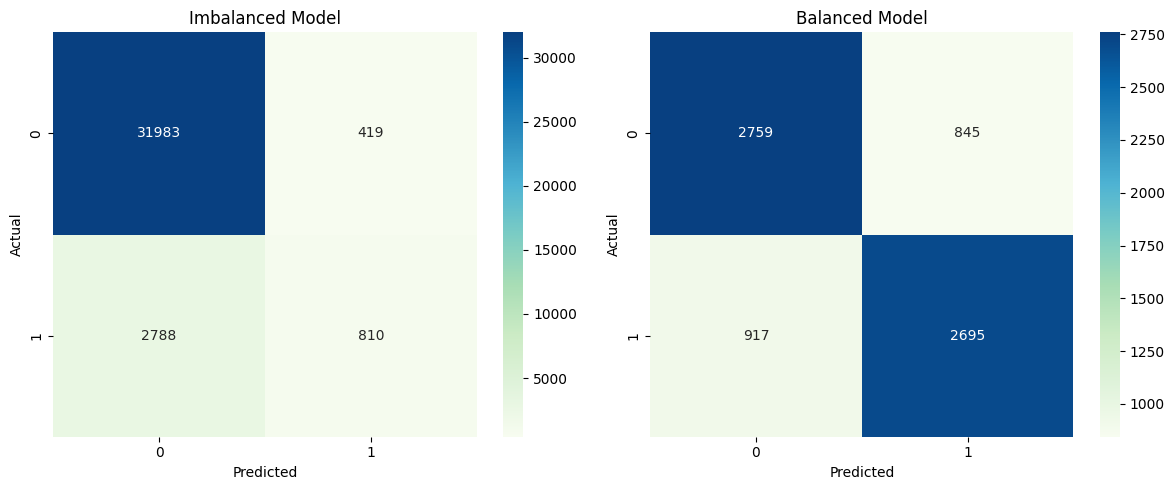

In [38]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Imbalanced model confusion matrix
cm = confusion_matrix(y_test, y_pred)
# Balanced model confusion matrix
cm_bal = confusion_matrix(y_test_bal, y_pred_bal)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='GnBu', ax=axes[0])
axes[0].set_title('Imbalanced Model')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')
sns.heatmap(cm_bal, annot=True, fmt='d', cmap='GnBu', ax=axes[1])
axes[1].set_title('Balanced Model')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')
plt.tight_layout()
plt.show()

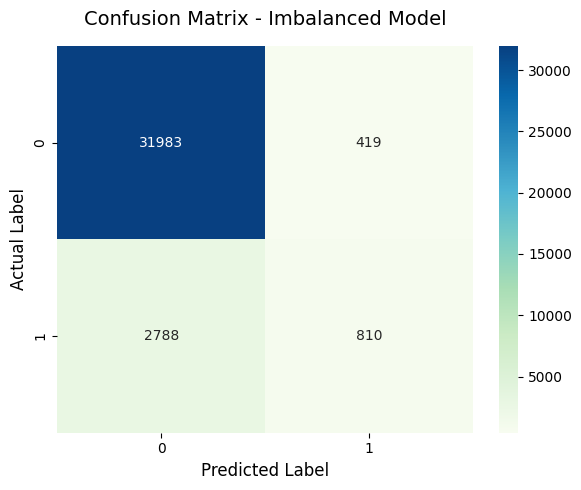

In [39]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Compute matrix for the imbalanced data
cm = confusion_matrix(y_test, y_pred)

# Set up a standalone figure
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='GnBu')

# Add labels and title
plt.title('Confusion Matrix - Imbalanced Model', fontsize=14, pad=15)
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('Actual Label', fontsize=12)

plt.tight_layout()
plt.show()

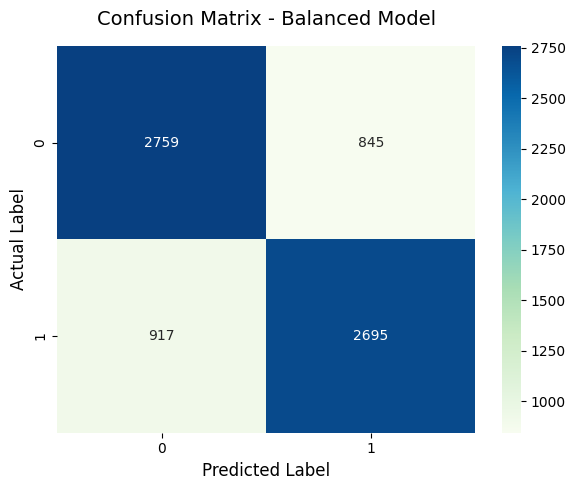

In [40]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Compute matrix for the balanced data
cm_bal = confusion_matrix(y_test_bal, y_pred_bal)

# Set up a standalone figure
plt.figure(figsize=(6, 5))
sns.heatmap(cm_bal, annot=True, fmt='d', cmap='GnBu')

# Add labels and title
plt.title('Confusion Matrix - Balanced Model', fontsize=14, pad=15)
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('Actual Label', fontsize=12)

plt.tight_layout()
plt.show()

## Communicate the Results



22. Communicate the results of your analysis.

### Key Findings

- My raw model showed a misleading 91.1% accuracy because 90% of the dataset consists of non-buyers. A useless model that simply guesses "nobody buys" would score 90% accuracy without finding a single customer.

- When evaluated using a confusion matrix, the imbalanced model completely missed 2,788 out of 3,598 actual buyers (False Negatives), making it commercially unviable.

- Forcing a 50/50 balanced dataset dropped overall accuracy to 75.4% but completely repaired the model's predictive utility.

- By training on balanced data, the model successfully flagged 2,695 true buyers, dramatically reducing missed revenue opportunities.


- ***Statistical Blueprint Validated: Before modeling, my grid of feature histograms confirmed healthy Gaussian distributions, and my heatmap proved absolute feature independence, completely validating our algorithm choice.***

### Recommendation

- Deploy the Balanced Gaussian Naive Bayes Model. In a customer transaction pipeline, a False Negative (missing a real customer who wanted to buy) is far more expensive than a False Positive (marketing to someone who doesn't buy). While the balanced model has a lower headline accuracy score, it is the superior business tool because it actively catches actual revenue.

- Next Steps: For future iterations, use this 75.4% balanced baseline to test more advanced ensemble models like XGBoost or Random Forest to push predictive accuracy past the 80% mark.

## Submit Final Project

23. Upload your finished Jupyter notebook to your Project 1 student folder.
